In [ ]:
#PyTorch张量：创建、索引、切片、形状变换（view, reshape).
import torch
#创建张量常用方法
#从列表创建
t1=torch.tensor([1,2,3])#从列表或者数组创建张量
t1=torch.zeros(2,3);t1=torch.ones(2,3);t1=torch.eye(3);t1=torch.rand(2,3);t1=torch.randn(2,3)
#全0,全1张量 两行三列。eye是单位矩阵。rand生成随机张量[0,1)均匀分布。
t1=torch.arange(0,10,2) #等差数列0 2 4 6 8
t1=torch.randn(4,5);t1=torch.stack([t1+5,t1,t1+2])#变为三维[3,4,5]
print(f"shape:{t1.shape}")

#索引,切片
x=torch.arange(16).reshape(4,4)
print(f"第一行{x[0]}\n")#x[0,0] x[-1,-1]最后一行最后一列数据
print(f"{x[:2]}\n{x[1:4,2:4]}\n每隔1列取1列\n{x[:,::2]}")#2是步长
indices=[[0,1,2],[1,2,3]]#取指定位置元素{(0,1),(1,2),(2,3)}
print(f"指定位置元素:{x[indices[0],indices[1]]}")
print(x[[0,1,2], [1,2,3]])#方式2
print(x[x>5])

In [ ]:
import torch
x=torch.arange(12)
x_3x4=x.view(3,-1)#-1表示自动推断维度
x_1x12=x.reshape(-1)#变为1维
x=torch.randn(2,3);x1=x.T
print(x.T.shape)
#z=增加/减少维度
x_unsqueeze=x.unsqueeze(0)#在第0维增加1维(1,2,3) 1维(2,1,3)。只加维度
x_squeeze=x_unsqueeze.squeeze(0)#(2,3)
#改变维度顺序
x=torch.randn(2,3,4);x_ord=x.permute(1,0,2)
# x形状(2,3,4)变为x_ord(3,2,4)。
print(f"{x}\n{x_ord}")

In [ ]:
import torch
#多变量自动求导
x1=torch.tensor([1.0,2.0,3.0],requires_grad=True)
x2=torch.tensor([4.0,2.0,-2.0],requires_grad=True)
y=x1**2+2*x1*x2+x2**3
y.sum().backward()
print(f"2*x1+2*x2:{x1.grad}")
print(f"2*x2+3*x2^2:{x2.grad}")
#梯度累积
x=torch.tensor(2.0,requires_grad=True)
y1=x**2;y1.backward()
print(x.grad)#4
x.grad.zero_() #用zero后变为12
y2=x**3;y2.backward()
print(x.grad) #4+12=16

In [ ]:
import torch
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# 1. 手动验证 y = x^3 的梯度
x = torch.tensor([1.0, 2.0, 3.0], requires_grad=True)
y = x ** 3
y.sum().backward()
print("梯度 (3x^2):", x.grad)   # 应该是 [3, 12, 27]
x.grad.zero_()

# 2. 绘制梯度曲线（不显示，只保存图片）
x_vals = torch.linspace(-3, 3, 20, requires_grad=True)
y_vals = x_vals ** 3
y_vals.sum().backward()
gradients = x_vals.grad.detach().numpy()

plt.figure(figsize=(10, 5))
X_np=x_vals.detach().numpy();y_np=y_vals.detach().numpy()
plt.subplot(1, 2, 1)
plt.plot(X_np,y_np, 'b-', linewidth=2, label='y = x³')
plt.xlabel('x')
plt.ylabel('y')
plt.title('function y = x³')
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(X_np, gradients, 'r-', linewidth=2, label="dy/dx = 3x²")
plt.xlabel('x')
plt.ylabel('dy/dx')
plt.title('grad dy/dx')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()
plt.close()

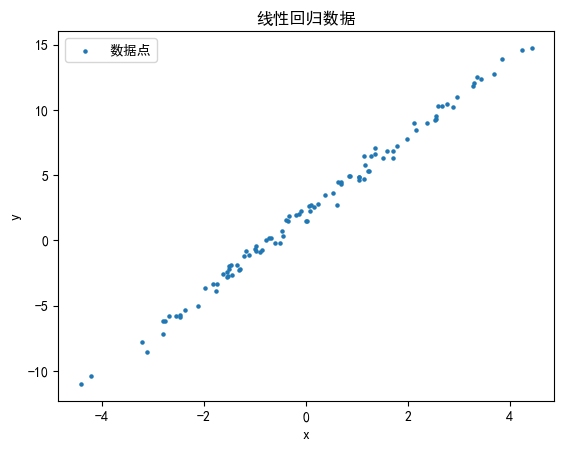

手动回归结果:w=3.0030,b=2.0177


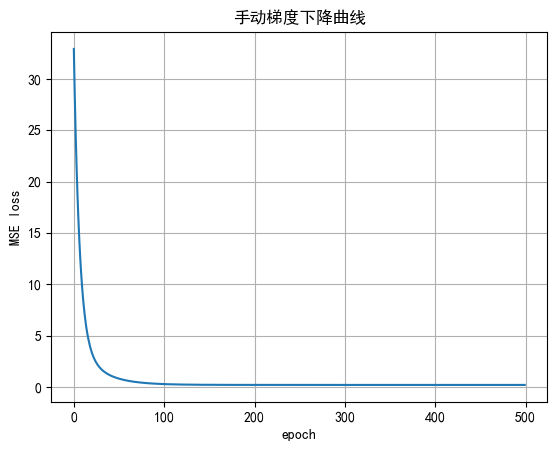

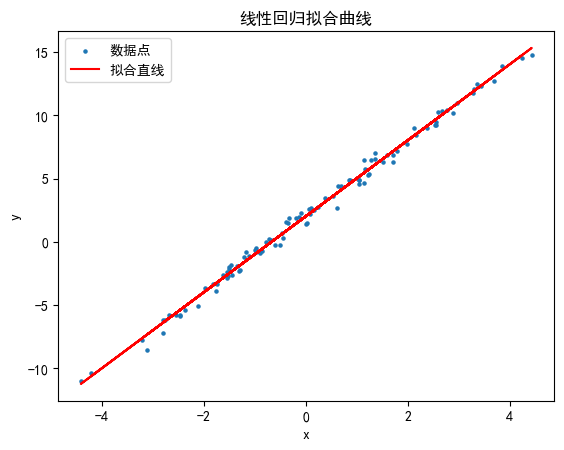

In [9]:
#手写线性回归：定义 w 和 b 张量（不是nn.Linear）。 手动实现：前向传播、手动计算梯度、手动更新参数
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import torch
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']        # 使用黑体
plt.rcParams['axes.unicode_minus'] = False          # 解决负号显示异常
#生成合成数据
torch.manual_seed(42)
X=torch.randn(100,1)*2 #特征(100,1)
true_w=3.0;true_b=2.0
y=true_w*X+true_b+torch.randn(100,1)*0.5 #加噪音 (100,1)
X_vals=X.detach().numpy();y_vals=y.detach().numpy()
plt.scatter(X_vals,y_vals,s=5,label='数据点')
plt.xlabel('x')
plt.ylabel('y')
plt.title('线性回归数据')
plt.legend()
plt.show()
#手写线性回归
w=torch.randn(1,requires_grad=True)#生成一个随机数据
b=torch.randn(1,requires_grad=True)
lr=0.01
epochs=500
losses=[]
for epoch in range(epochs):
    #前向传播
    y_pred=X*w+b
    #损失函数
    loss=((y_pred-y)**2).mean()
    losses.append(loss.item())
    loss.backward()#计算梯度
    with torch.no_grad():
        w-=lr*w.grad
        b-=lr*b.grad
    w.grad.zero_()
    b.grad.zero_()
print(f"手动回归结果:w={w.item():.4f},b={b.item():.4f}")
#画损失曲线
plt.plot(range(epochs),losses)
plt.xlabel('epoch')
plt.ylabel('MSE loss')
plt.title('手动梯度下降曲线')
plt.grid(True)
plt.show()
#画拟合曲线
y_fit=X*w+b
plt.scatter(X.numpy(),y.numpy(),s=5,label='数据点')
plt.plot(X.numpy(),y_fit.detach().numpy(),'r-',label='拟合直线')
plt.xlabel('x')
plt.ylabel('y')
plt.title('线性回归拟合曲线')
plt.legend()
plt.show()

nn.Linear 结果: w = 3.0030, b = 2.0178
真实值: w = 3.0, b = 2.0


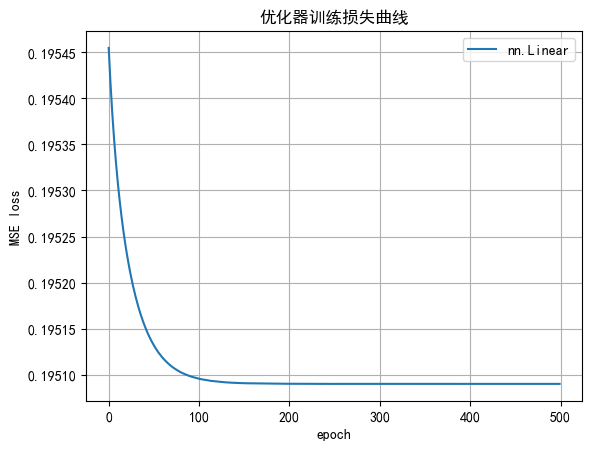

In [21]:
#使用nn.Linear+优化器
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import torch
import torch.nn as nn
import torch.optim as optim
torch.manual_seed(42)
X=torch.randn(100,1)*2 #特征(100,1)
true_w=3.0;true_b=2.0
y=true_w*X+true_b+torch.randn(100,1)*0.5
#定义模型
model=nn.Linear(1,1) #输入特征1,输出特征1。内部自动创建两个张量。model.weight(ou_fea,in_fea);model.bias(ou_fea,)=(1,)
with torch.no_grad():
    model.weight.fill_(true_w)# 将权重初始化为真实值 3.0
    model.bias.fill_(true_b) # 将偏置初始化为真实值 2.0
criterion=nn.MSELoss()#均方误差损失
optimizer=optim.SGD(model.parameters(),lr=0.01)#随机梯度下降优化器 model.paraments返回模型所有需要训练的参数
#训练
epochs=500;losses_nn=[]
for epoch in range(epochs):    
    y_pred = model(X)#前向传播:输入X,输出预测值(100,1)
    loss = criterion(y_pred, y)
    losses_nn.append(loss.item())
    # 反向传播
    optimizer.zero_grad()
    loss.backward()#反向传播:计算损失对每个参数的梯度
    optimizer.step()#更新参数 更新 w b
w_nn = model.weight.item()#提取训练后的参数
b_nn = model.bias.item()
print(f"nn.Linear 结果: w = {w_nn:.4f}, b = {b_nn:.4f}")
print(f"真实值: w = {true_w}, b = {true_b}")
plt.plot(range(epochs), losses_nn, label='nn.Linear')
plt.xlabel('epoch')
plt.ylabel('MSE loss')
plt.title('优化器训练损失曲线')
plt.legend()
plt.grid(True)
plt.show()